In [17]:
import numpy as np
import csv
import math 
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LogNorm
import matplotlib.cm as cm
#import sys

file_raster = './rastert_dem_uni1-clean.txt' ## DEM file 
#file_shower_txt = './energia_split_data_3.txt' ## file de energía
file_shower_txt = '~/Work/split_files3/Dlim-2201-01_08640007.txt' ## file de energía

fila = 240 ## (por qué?)
n,m = 300,120 #punto de observación (X,h)
apertura = 15 #apertura del ángulo 
escala_satelite = 3 # escala en X de acuerdo a datos de CONIDA (unidades?)

angle_observation = 90 # ángulo phi de observación en coordenadas de CORSIKA

phi1, phi2 = 89, 91 #posición de observación en coordenadas de CORSIKA
anglet = 10 #apertura en azimutal

In [18]:
## inicio del programa 

cmap = plt.colormaps['viridis']

num_colors = 20
color = cmap(np.linspace(0, 1, num_colors))

## línea de visión 
def recta(x_0, y_0, x, angulo): # todos los puntos son conocidos, la función bota un punto adelante 
 #   print(x_0, y_0, x, angulo)
    y_recta= y_0+np.tan(np.radians(angulo))*(x-x_0)     

    return y_recta 
 
############################ 
# calcula el p0
# compara el array del cerro con la recta y da el valor de intersección
# pt_ob = (pt_obx, pt_oby) , array = valor en y del objeto cerro , array_recta = valores de y de la recta en la
# array_x = valores en x
# dirección de observación 

def pto_0(pt_ob, array_x, array): 
    for i in range(pt_ob[0], len(array_x)):
        if pto_0[1]==array[i]: 
            pto_inicial= i
    return (pto_inicial, pto_0[1])

def indice_p2(pt_ob, array_x, array_cerro, array_recta):  #indice final de cruce 
    indice_inicial = 0
    for i in range(pt_ob[0], len(array_x)):
        if (array_recta[i]-array_cerro[i])<0: 
            indice_inicial = i            
                
    return (indice_inicial, array_cerro[indice_inicial])

def indice_p1(pt_ob, array_x, array_cerro, array_recta):  #indice inicial de cruce 
    indice_final = 0
    for i in range(pt_ob[0], len(array_x)):
        if (array_recta[i]-array_cerro[i])<0: 
            indice_final = i
            break
                
    return (indice_final, array_cerro[indice_final])
    
def distancia(p1, p2): #distancia entre dos puntos 
 
    dist = math.sqrt((p2[1]-p1[1])**2 + ((p2[0]-p1[0])*escala_satelite)**2)  
    return dist  

In [19]:
## CÁLCULO DEL LA ELEVACIÓN MÁXIMA DE OBSERVACION


def angulo_maximo(arr_x, np_array, p): #arra_x: indices en el eje X, fila: fila de analisis, p: punto de observación 
        vec_picos = []
        vec  = []
        ind_z = 0 
        ind_x = 0 
    
        for j in range(p[0], len(arr_x)): 
            if np_array[j] > ind_z:
                ind_z = np_array[j]
                ind_x = j 
    
        vec_picos.append(ind_x)
        vec_picos.append(ind_z)

        h_max = ind_z-p[1]
        x_max = arr_x[ind_x]-p[0]  
    
        phi_max = np.degrees(np.arctan2(h_max,x_max))

#        print(ind_z,ind_x,h_max,x_max,phi_max)
    
        return (vec_picos, phi_max) #ángulo en grados

In [20]:
#ecuaciones de pérdida de energía 

def funciondEdX_lesparre(E):  
    l4 = 0.0154 
    l3 = -0.0461 
    l2 = 0.0368
    l1 = 0.0801
    l0 = 0.2549
    y = math.log10(E)
    dEdx = 10**(l4*y**4+l3*y**3+l2*y**2+l1*y**1+l0)
    
    return dEdx
        

def funciondEdX_tesis(E): 
    me = 0.0005285 #GeV/c2
    mu = 0.1057 #GeV/c2
    
    Emax = (E**2)/(E+(mu**2)/(2*me))
    dEdx = (1.84 + 0.076* np.log(Emax/(mu)))
     
    return dEdx
        
#################################  

def perdida_energia_total(E, d): #energia y distancia por recorrer segun lesparre

    E = E*1000  #(E in Mev)
    step_size = 1 #m
    avg_dens = 2.64 #g/cm^3

#    print("Initial parameters (Lesparre) - Energy:",E,"d:",d,"step_size:",step_size)
    
    total_loss = 0
    j=0
#    for _ in np.arange(0, d, step_size):
    for j in range(0,d): # distancia en metros --> step_size en metros (unidades 
        j=j+1
        dE_dx = funciondEdX_lesparre(E)
        energy_loss = dE_dx * step_size * avg_dens # Energy loss in the step        
        E = E - energy_loss
    
        if E < 0 : 
            control = False
            break 
        control = True

        #print(j,"dEdx:",dE_dx,"E loss:",energy_loss,"E:",E)
    
    energia_final = E 
    
    return (energia_final, control)
    #Control True = pasó, False = no pasó

#################################  

def perdida_energia_total_tesis(E, d): #energia y distancia por recorrer segun lesparre

    E_t = E*1000  #(E in Mev)
    step_size = 1 #m
    avg_dens = 2.64 #g/cm^3

#    print("Initial parameters (Tesis) - Energy:",E_t,"d:",d,"step_size:",step_size)
    
    total_loss = 0
    j=0
#    for _ in np.arange(0, d, step_size):
    for j in range(0,d): # distancia en metros --> step_size en metros (unidades 
        j=j+1
        dE_dx_t = funciondEdX_tesis(E_t)
        energy_loss_t = dE_dx_t * step_size * avg_dens # Energy loss in the step        
        E_t = E_t - energy_loss_t
    
        if E_t < 0 : 
            control_t = False
            break 
        control_t = True

        #print(j,"dEdx:",dE_dx,"E loss:",energy_loss,"E:",E)
    
    energia_final_t = E_t 
    
    return (energia_final_t, control_t)
    #Control True = pasó, False = no pasó

#################################  
   
## Diccionario de distancias 

def acceder_diccionario(diccionario, valor_clave):
    valor_distancia = 0 
    for clave, valor in diccionario.items(): 
        if clave == valor_clave: 
            valor_distancia = diccionario[valor_clave]
    return valor_distancia 

In [21]:
df_shower_txt  = pd.read_csv(file_shower_txt, sep =" ")# Lee los datos del shower en energia y ángulo
df  = pd.read_csv(file_raster, sep =" ", header=None)# Lee los datos del raster del objeto
df  = df.fillna(0)
df  = df.drop(columns=626)#eliminar la última columna  (columna principalmente de ceros)

#print(df)

#dimensionalidad del raster
n_col = df.shape[1] 
n_fil = df.shape[0]

arr_z_cerro = []
arr_x = np.linspace(0,n_col-1,n_col) #crea los índices en x (n_col) para iterar 

pt_ob = [n,m] #punto de observación (300,120) -> (x,h)
arr_z_cerro = df.iloc[fila].to_numpy() #elevación del cerro en una determinada fila

ang_max = int(np.round(angulo_maximo(arr_x, arr_z_cerro, pt_ob)[1])) #ángulo máximo de observación para una fila 

theta1, theta2 = ang_max - apertura, ang_max-2.0 #angulos de observación para una fila dada i límites de observación

In [24]:
################################# IMPORTANTE #################################
df_shower_txt3 = df_shower_txt

#df_shower_txt3 = df_shower_txt[(df_shower_txt['part'] ==5) | (df_shower_txt['part'] ==6)] #<---------------------
data_shower = df_shower_txt3.sort_values(by=df_shower_txt3.columns[1]) #data ordered by phi angle

########### IMPORTANTE #################################

#dfshower_pre_filtrado = data_shower[ (data_shower['phit'] >= angle_observation-anglet) & (data_shower['phit'] <= angle_observation+anglet) &(data_shower['thetat'] >= theta1) & (data_shower['thetat'] <= ang_max)]

dfshower_pre_filtrado = data_shower[ (data_shower['thetat'] >= theta1) & (data_shower['thetat'] <= ang_max)] #data selected by theta angle limits
dfshower_filtrado = dfshower_pre_filtrado.drop('part', axis=1) 

#print(dfshower_filtrado)

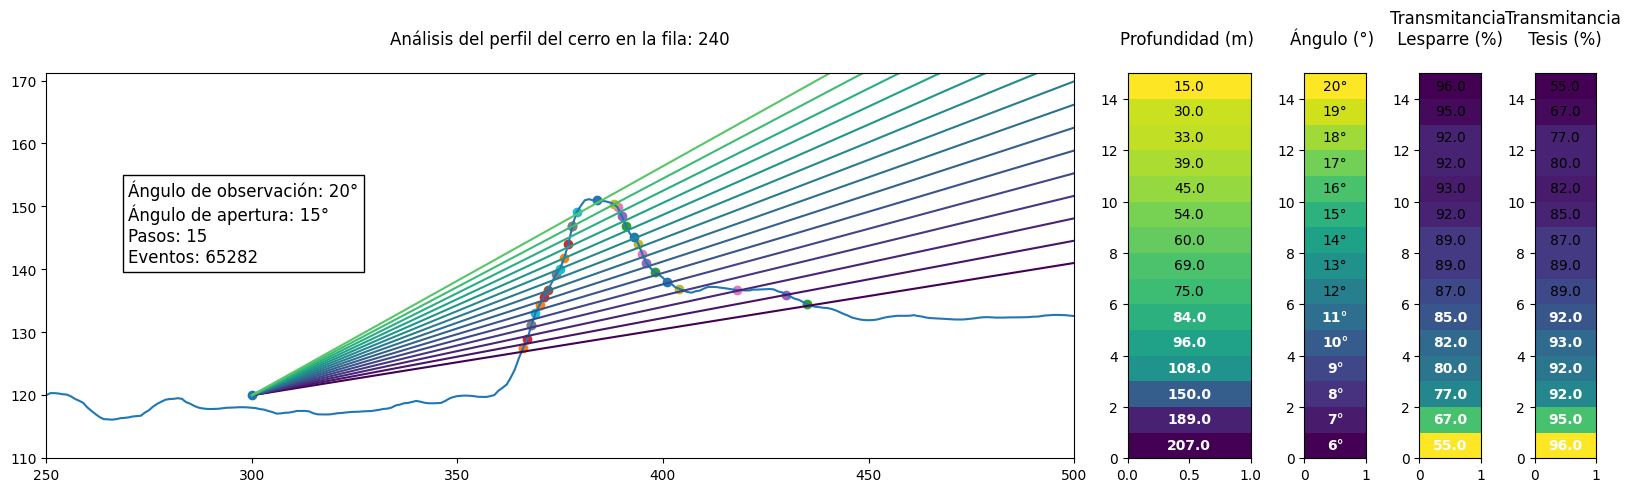

In [25]:
fig, axs = plt.subplots(1, 5,figsize=(20,5), gridspec_kw={'width_ratios': [5, 0.6,0.3,0.3,0.3]})  # 2 filas, 1 columna de subplots

############
#PLOT 0 del perfil UNI y puntos de intersección 
############ 
axs[0].plot(arr_z_cerro)
axs[0].scatter(pt_ob[0], pt_ob[1])

#coordenadas (x,h) de intersección entre la proyección de observación y el perfil del cerro, para cada ángulo analizado
vec_dis=[] #vector con la fila, el ángulo de observación y la profundidad
j=0
p2_max = 0
axs[0].set_title("Análisis del perfil del cerro en la fila: "+str(fila)+'\n') 
for th_i in range(theta1, ang_max,1):
    h_line = recta(pt_ob[0], pt_ob[1], arr_x, th_i)
    p2 = indice_p2(pt_ob, arr_x, arr_z_cerro, h_line)  #ptos obs, indice de columnas, alturas de la fila seleccionada, array de alturas (puntos) de la recta para diferentes ángulos
    p1 = indice_p1(pt_ob, arr_x, arr_z_cerro, h_line) 

    if (p2[0]>p2_max): #upper limit to project the line
        p2_max = p2[0]+30
    
#    print(p1,p2,p2_max)

    if (p2[0]!=0) or (p1[0]!=0):         
        axs[0].plot(arr_x[n:], h_line[n:], color=color[j])    #proyecciones de observación
        axs[0].scatter(p1[0], p1[1]) #ptos. de observación inicial
        axs[0].scatter(p2[0], p2[1]) #ptos. de observación final

        d = (distancia(p1,p2))
        evento = [fila,th_i,d]  #los valores registrados son azimutales, los valores en el plot son elevación
        elevacion_max = th_i 
        vec_dis.append(evento)  # fila, th_i angulo de observación, distancia 
        j=j+1 #indice para los colores

texto = 'Ángulo de observación: '+str(round(elevacion_max))+'°'+'\nÁngulo de apertura: '+str(apertura)+'°'+'\nPasos: '+ str(j) +'\nEventos: '+ str(len(dfshower_pre_filtrado))
x_pos = n-30 # valor 20 de posición de texto en X
y_pos = np.max(arr_z_cerro) -10 # valor de posición de caja de texto en Y 
axs[0].text(x_pos, y_pos, texto,fontsize = '12', bbox=dict(facecolor='white', edgecolor='black', linewidth=1))
axs[0].set_xlim(n-50,500) 
axs[0].set_ylim(110, np.max(arr_z_cerro)+20)

############
#PLOT 1 de la distancia
############
#vec_dis matrix con los valores de observación y distancia para cada evento
a_vec_dis=[] #vector con los valores de profundidad desde un punto de observación dado por vec_dis. 
#vec_dis = [fila, ángulo, distancia] 

for i in range(len(vec_dis)):
    r = vec_dis[i][2] #registra solo la distancia 
    a_vec_dis.append(np.round(r,0))

#######################################################----------------------------#
a_vec_dis = np.array(a_vec_dis) #registra las distancias de los ángulos disponibles para la observación desde un punto de observación 
a_vec_dis = a_vec_dis[::-1] #ordena demenor a mayor

matriz = np.tile(a_vec_dis, (1,1))
matriz_rotada_distancias_observacion = np.rot90(matriz)

#print(matriz_rotada_distancias_observacion)

axs[1].set_title("Profundidad (m) \n")

im = axs[1].pcolormesh(matriz_rotada_distancias_observacion,cmap="viridis_r")

for i in range(matriz_rotada_distancias_observacion.shape[0]):
    for j in range(matriz_rotada_distancias_observacion.shape[1]): 
        if i <= 5:         
            axs[1].text(j+0.5, i+0.5, str(matriz_rotada_distancias_observacion[i,j]), fontweight='bold',  color='white', ha='center', va='center')
        else: 
            axs[1].text(j+0.5, i+0.5, str(matriz_rotada_distancias_observacion[i,j]), color='black', ha='center', va='center')

################
#PLOT 2: Ángulos de observación con distancia diferente de 0 
############

b_vec_dis=[] #vector con los valores de profundidad tomada de vec_dis
#vec_dis = [fila, ángulo, distancia] 

for i in range(len(vec_dis)):
    rr = vec_dis[i][1] #registra solo los ángulos 
    b_vec_dis.append(np.round(rr,2))

b_vec_dis = np.array(b_vec_dis)
b_vec_dis=b_vec_dis[::-1] 
matriz_2 = np.tile(b_vec_dis, (1,1))
matriz_rotada_angulos_observacion = np.rot90(matriz_2)

axs[2].set_title("Ángulo (°) \n")

io = axs[2].pcolormesh(matriz_rotada_angulos_observacion,cmap="viridis")

for i in range(matriz_rotada_angulos_observacion.shape[0]):
    for j in range(matriz_rotada_angulos_observacion.shape[1]):
        if i <= 5:         
            axs[2].text(j+0.5, i+0.5, str(matriz_rotada_angulos_observacion[i,j])+'°', fontweight='bold',color='white', ha='center', va='center')
        else: 
            axs[2].text(j+0.5, i+0.5, str(matriz_rotada_angulos_observacion[i,j])+'°',  color='black', ha='center', va='center')

################################################
## Cálculo de la atenuación
################################################

diccionario = {}  # Inicializar el diccionario vacío
#vec_dis = [fila, angulo, distancia] 
for i in range(0, len(vec_dis)):  # Bucle for para generar claves del 1 al 5
    clave = vec_dis[i][1] #valores de distancia
    valor = vec_dis[i][2] #valores de ángulos    
    diccionario[clave] = valor  # Agregar clave-valor al diccionario  

#print(diccionario)

veco=[] #array con los valores de phi , theta, distancia recorrida, Einicial, Efinal, Control

angulos_atenuados = []
veco_tesis  = []
#del data_shower

########### REVISAR ###########
#dfshower_filtrado datos de las lluvias de muones entrantes
#dfshower_filtrado = phit , thetat , Et
#para todos los eventos se calcula la atenuación 

for j in range(len(dfshower_filtrado)):  
#for j in range(10): #to test     
    if dfshower_filtrado.iloc[j,1] <= elevacion_max: 
        angulos_atenuados.append(dfshower_filtrado.iloc[j,1])              
        temp_angulo_shower = dfshower_filtrado.iloc[j,1] # ángulo theta del evento j en el shower
        temp_energia_shower = dfshower_filtrado.iloc[j,2] # energía inicial del evento 
        
        temp_distancia_x_angulo = acceder_diccionario(diccionario, temp_angulo_shower) ###############################################

        #print(temp_angulo_shower,temp_distancia_x_angulo)
     
        fin_ener, val_temp = perdida_energia_total(temp_energia_shower, round(temp_distancia_x_angulo)) #Condicional si la pérdida de energía del evento corresponde a haber salido o quedarse en el objeto 
        fin_ener_tesis, val_temp_tesis = perdida_energia_total_tesis(temp_energia_shower, round(temp_distancia_x_angulo)) #Condicional si la pérdida de energía del evento corresponde a haber salido o quedarse en el objeto 

#        print(j,val_temp,fin_ener,val_temp_tesis,fin_ener_tesis)

        res_atenua = [dfshower_filtrado.iloc[j,0], temp_angulo_shower, temp_distancia_x_angulo, temp_energia_shower, fin_ener, val_temp] 
        res_atenua_tesis = [dfshower_filtrado.iloc[j,0], temp_angulo_shower, temp_distancia_x_angulo, temp_energia_shower, fin_ener_tesis, val_temp_tesis] 

        veco_tesis.append(res_atenua_tesis)
        veco.append(res_atenua)

####################
#Tesis

df_atenuado_tesis = pd.DataFrame(veco_tesis, columns=['phi','theta','distancia', 'Energia_i', 'Energia_f', 'Control'])
df_atenuado_con_filtro_tesis=df_atenuado_tesis.groupby(['theta','Control'])['theta'].count().reset_index(name='count') 

conteo_tesis = df_atenuado_tesis.pivot_table(index='theta', columns='Control', aggfunc='size', fill_value=0).reset_index()
conteo_tesis['transmitancia'] = np.round( conteo_tesis.iloc[:, 2] / (conteo_tesis.iloc[:, 1]+conteo_tesis.iloc[:, 2] ), 3)
conteo_tesis['pasaron'] = np.round( (conteo_tesis.iloc[:, 2] ), 3)
conteo_tesis['total'] = np.round( (conteo_tesis.iloc[:, 1]+conteo_tesis.iloc[:, 2] ), 3)
vec_angle_tesis = conteo_tesis['theta'].to_numpy()
vec_atenuado_tesis = np.round(conteo_tesis['transmitancia'].to_numpy()*100)

#################
#Lesparre 
df_atenuado = pd.DataFrame(veco, columns=['phi','theta','distancia', 'Energia_i', 'Energia_f', 'Control'])
#df_atenuado = pd.DataFrame(veco, columns=['theta','distancia', 'Energia_i', 'Energia_f', 'Control'])
# filtramos por valores de control si pasó o no el evento
# df_atenuado_filtro tiene el valor de theta para aquellos que pasaron y los que no
# df_atenuado_filtro hace el conteo de valores para los que pasaron y no en base al control
df_atenuado_con_filtro=df_atenuado.groupby(['theta','Control'])['theta'].count().reset_index(name='count') 

conteo = df_atenuado.pivot_table(index='theta', columns='Control', aggfunc='size', fill_value=0).reset_index()
conteo['transmitancia'] = np.round( conteo.iloc[:, 2] / (conteo.iloc[:, 1]+conteo.iloc[:, 2] ), 3)
conteo['pasaron'] = np.round( (conteo.iloc[:, 2] ), 3)
conteo['total'] = np.round( (conteo.iloc[:, 1]+conteo.iloc[:, 2] ), 3)
vec_angle = conteo['theta'].to_numpy()
vec_atenuado = np.round(conteo['transmitancia'].to_numpy()*100)

################################################
## Fin del cálculo de la atenuación
################################################
## Calculamos el porcentaje de atenuación

data_porcentaje = np.array(vec_angle)

############
#PLOT 3
############
data_angle = np.array(vec_atenuado)
data_angle=data_angle[::-1] 

 
matriz_3 = np.tile(data_angle, (1,1))
matriz_rotada_3 = matriz_3
matriz_rotada_3 = np.rot90(matriz_3) 

axs[3].set_title("Transmitancia \n Lesparre (%) \n")
 
iu = axs[3].pcolormesh(matriz_rotada_3,cmap="viridis_r")

for i in range(matriz_rotada_3.shape[0]):
    for j in range(matriz_rotada_3.shape[1]): 
        if i <= 5:         
            axs[3].text(j+0.5, i+0.5, str(matriz_rotada_3[i,j]), fontweight='bold', color='white', ha='center', va='center')
            
        else: 
            axs[3].text(j+0.5, i+0.5, str(matriz_rotada_3[i,j]), color='black', ha='center', va='center')
        

############
#PLOT 4  Transmitancia Tesis
############
data_angle_tesis = np.array(vec_atenuado_tesis)
data_angle_tesis=data_angle[::-1] 

 
matriz_4 = np.tile(data_angle_tesis, (1,1))
#matriz_rotada_4 = matriz_4
matriz_rotada_4 = np.rot90(matriz_4) 

axs[4].set_title("Transmitancia \n Tesis (%) \n")
 
iu = axs[4].pcolormesh(matriz_rotada_3,cmap="viridis_r")

for i in range(matriz_rotada_4.shape[0]):
    for j in range(matriz_rotada_4.shape[1]): 
        if i <= 5:         
            axs[4].text(j+0.5, i+0.5, str(matriz_rotada_4[i,j]), fontweight='bold', color='white', ha='center', va='center')
            
        else: 
            axs[4].text(j+0.5, i+0.5, str(matriz_rotada_4[i,j]), color='black', ha='center', va='center')
             
######################################

 
 
plt.show()